<a href="https://colab.research.google.com/github/LleilaA13/Thesis-MUL/blob/master/notebooks/resnettutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##### Licensed under the Apache License, Version 2.0 (the "License");

In [ ]:
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

<img src="https://raw.githubusercontent.com/greentfrapp/lucent/master/images/lucent_header.jpg" width="600"></img>

# Lucent Tutorial

A Colab notebook following the spirit of Lucid's notebooks.



## Install, Import, Load Model

In [ ]:
!pip install --quiet git+https://github.com/greentfrapp/lucent.git

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 121.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 90.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 57.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 43.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import torch
from torchvision import models

def load_resnet18(path):
    model = models.resnet18(num_classes=10)
    checkpoint = torch.load(path, map_location='cuda', weights_only=False)
    try:
        model.load_state_dict(checkpoint['state_dict'], strict=False)
    except:
        model.load_state_dict(checkpoint, strict=False)
    model.eval()
    return model

original_model = load_resnet18("/content/drive/MyDrive/THESIS/0checkpoint.pth.tar")
unlearned_model = load_resnet18("/content/drive/MyDrive/THESIS/RLcheckpoint.pth.tar")

Available layers in the model:
['conv1', 'bn1', 'relu', 'maxpool', 'layer1', 'layer1_0', 'layer1_0_conv1', 'layer1_0_bn1', 'layer1_0_relu', 'layer1_0_conv2', 'layer1_0_bn2', 'layer1_1', 'layer1_1_conv1', 'layer1_1_bn1', 'layer1_1_relu', 'layer1_1_conv2', 'layer1_1_bn2', 'layer2', 'layer2_0', 'layer2_0_conv1', 'layer2_0_bn1', 'layer2_0_relu', 'layer2_0_conv2', 'layer2_0_bn2', 'layer2_0_downsample', 'layer2_0_downsample_0', 'layer2_0_downsample_1', 'layer2_1', 'layer2_1_conv1', 'layer2_1_bn1', 'layer2_1_relu', 'layer2_1_conv2', 'layer2_1_bn2', 'layer3', 'layer3_0', 'layer3_0_conv1', 'layer3_0_bn1', 'layer3_0_relu', 'layer3_0_conv2', 'layer3_0_bn2', 'layer3_0_downsample', 'layer3_0_downsample_0', 'layer3_0_downsample_1', 'layer3_1', 'layer3_1_conv1', 'layer3_1_bn1', 'layer3_1_relu', 'layer3_1_conv2', 'layer3_1_bn2', 'layer4', 'layer4_0', 'layer4_0_conv1', 'layer4_0_bn1', 'layer4_0_relu', 'layer4_0_conv2', 'layer4_0_bn2', 'layer4_0_downsample', 'layer4_0_downsample_0', 'layer4_0_downsample

100%|██████████| 512/512 [01:09<00:00,  7.32it/s]



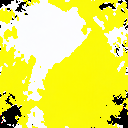

100%|██████████| 512/512 [01:06<00:00,  7.64it/s]



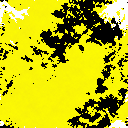

In [ ]:
from lucent.modelzoo.util import get_model_layers
from lucent.optvis import render, param, transform, objectives

print("Available layers in the model:")
print(get_model_layers(original_model))

print("Available layers in the model:")
print(get_model_layers(unlearned_model))

# Example: visualizing filters from conv1
_ = render.render_vis(original_model, "conv1:0", show_inline=True)
_ = render.render_vis(unlearned_model, "conv1:0", show_inline=True)


Similar to [Lucid](https://github.com/tensorflow/lucid/), this tutorial will be focused on the same InceptionV1 model, also known as GoogLeNet.

Check out the original GoogLeNet paper [here](https://research.google.com/pubs/archive/43022.pdf).

[Distill](https://distill.pub) also has a fascinating [article](https://distill.pub/2017/feature-visualization/) on this topic that includes visualizations of all the InceptionV1 neurons.


`render_vis` has a few nice defaults so we can get started quickly!

## Fiddling with the Knobs

Just like Lucid, Lucent splits visualizations into *objectives*, *parameterizations* and *transforms*. To quote from Lucid's tutorial:

* **Objectives** -- What do you want the model to visualize?
* **Parameterizations** -- How do you describe the image?
* **Transforms** -- What transformations do you want your visualization to be robust to?

### Objectives

What loss function do we want to minimize?

Or from another point of view, what part of the model do we want to understand?

In essence, we are trying to generate an image that causes a particular neuron or filter to activate strongly. The objective allows us to select a specific neuron, channel or a mix!

100%|██████████| 512/512 [02:05<00:00,  4.09it/s]



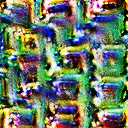

In [ ]:
# The default is optimizing for a channel/filter
obj = objectives.channel("layer3_1_conv2", 10)
_ = render.render_vis(original_model, obj, show_inline=True)

100%|██████████| 512/512 [02:04<00:00,  4.11it/s]



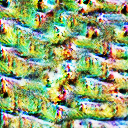

In [ ]:
# The default is optimizing for a channel/filter
obj = objectives.channel("layer3_1_conv2", 10)
_ = render.render_vis(unlearned_model, obj, show_inline=True)

### Parameterizations

For an initial attempt at feature visualization, we might do gradient descent in the pixel space of a randomly initialized image. Unfortunately, this often creates images comprising high frequency noise, similar to [adversarial images](https://arxiv.org/abs/1312.6199).

Instead, the use of alternative parameterizations can produce more visually intuitive results, by operating in the frequency domain or using compositional pattern producing networks.

Recomended reading: Distill's Feature Visualization article, specifically the section on [Preconditioning and Parameterization](https://distill.pub/2017/feature-visualization/#preconditioning)

100%|██████████| 512/512 [00:04<00:00, 106.20it/s]



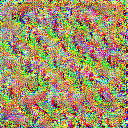

In [ ]:
# A visualization with gradient descent in pixel space
# Notice the high frequency components similar to adversarial images

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def param_f():
    params, image_f = param.image(128, fft=False, decorrelate=False)
    return params, lambda: image_f().to(device)

# We set transforms=[] to denote no transforms
original_model.to(device).eval()
# Try a different layer that was successfully visualized
obj = objectives.channel("layer3_1_conv2", 0) # Using channel 0 as an example
_ = render.render_vis(original_model, obj, param_f, transforms=[], show_inline=True)

100%|██████████| 512/512 [00:05<00:00, 100.44it/s]



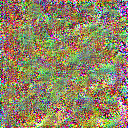

In [ ]:
# A visualization with gradient descent in pixel space
# Notice the high frequency components similar to adversarial images

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def param_f():
    params, image_f = param.image(128, fft=False, decorrelate=False)
    return params, lambda: image_f().to(device)

# We set transforms=[] to denote no transforms
unlearned_model.to(device).eval()
# Try a different layer that was successfully visualized
obj = objectives.channel("layer3_1_conv2", 0) # Using channel 0 as an example
_ = render.render_vis(unlearned_model, obj, param_f, transforms=[], show_inline=True)

100%|██████████| 512/512 [00:05<00:00, 94.81it/s] 



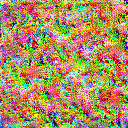

In [ ]:
# A visualization with gradient descent in Fourier basis

param_f = lambda: param.image(128, fft=True, decorrelate=False)
_ = render.render_vis(original_model, obj, param_f, transforms=[], show_inline=True)

100%|██████████| 512/512 [00:04<00:00, 112.88it/s]



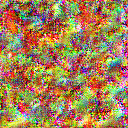

In [ ]:
# A visualization with gradient descent in Fourier basis

param_f = lambda: param.image(128, fft=True, decorrelate=False)
_ = render.render_vis(unlearned_model, obj, param_f, transforms=[], show_inline=True)

100%|██████████| 512/512 [00:04<00:00, 119.33it/s]



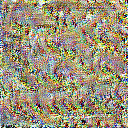

In [ ]:
# A visualization with channel decorrelation

param_f = lambda: param.image(128, fft=False, decorrelate=True)
_ = render.render_vis(original_model, obj, param_f, transforms=[], show_inline=True)

100%|██████████| 512/512 [00:04<00:00, 119.94it/s]



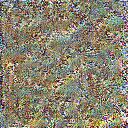

In [ ]:
# A visualization with channel decorrelation

param_f = lambda: param.image(128, fft=False, decorrelate=True)
_ = render.render_vis(unlearned_model, obj, param_f, transforms=[], show_inline=True)